# ATS & Over/Under Performance by Team
**NFL 2025 Season — Notebook 5**

> **Context:** The spread is the market's equaliser — it converts any game into a theoretical 50/50 bet by adjusting for perceived team strength. If a team consistently beats the spread, the market is systematically underpricing them. If they consistently fail to cover, the public money is inflating their line beyond what their actual performance justifies. This notebook builds the full ATS and O/U ledger for all 32 teams and identifies the clearest mispricing patterns of the 2025 season.

---

## Notebook Roadmap

| # | Section | What | Why |
|---|---------|------|-----|
| 1 | **Setup** | Load data, compute ATS and O/U results for every game | Uses opener spread — the book's initial uninfluenced price before public money distorts the line |
| 2 | **Overall ATS Results** | Season-wide away vs. home cover rates, binomial significance test | Validates market efficiency — a well-calibrated spread market should produce ~50% covers |
| 3 | **ATS by Team** | Cover rate for all 32 teams combined home and away | Identifies which teams are systematically under or over-rated by the market |
| 4 | **Trap Teams vs. Value Teams** | Win rate vs. cover rate scatter — identifies public darlings and underdog bargains | The most actionable finding for a sports bettor or analyst |
| 5 | **Home vs. Away ATS Split** | Per-team cover rate split by venue | Some teams cover far better at home or on the road — venue-specific market inefficiencies |
| 6 | **ATS by Week** | Average away cover rate across the season timeline | Patterns in how market efficiency shifts as the season progresses |
| 7 | **Over/Under Analysis** | Season O/U results, team over rates, total line tendencies | Tests whether the total market is efficient; identifies teams that consistently beat the total |
| 8 | **Export** | Save all outputs | Handoff for Notebooks 6 and 7 |

---

## 1. Setup

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from src.utils import load_data, BOOKS
from scipy.stats import binomtest

sns.set_theme(style='whitegrid', palette='muted')
pd.set_option('display.float_format', '{:.3f}'.format)

# ── Load ─────────────────────────────────────────────────────────────────────
df = load_data('../data/nfl2025_complete.xlsx')

for col in df.columns:
    if '_spread' in col or 'total_line' in col:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# ── ATS logic ─────────────────────────────────────────────────────────────────
# opener_away_spread: positive = away is underdog (+7), negative = away is fav (-3)
# away covers if: actual_margin + opener_away_spread > 0
# e.g. away loses 17-20 (margin=-3), spread=+7 → -3+7=+4 > 0 → away covers
df['actual_margin']  = df['away_score'] - df['home_score']
df['ats_away_cover'] = (df['actual_margin'] + df['opener_away_spread']) > 0
df['ats_home_cover'] = (df['actual_margin'] + df['opener_away_spread']) < 0
df['ats_push']       = (df['actual_margin'] + df['opener_away_spread']) == 0

# ── O/U logic ─────────────────────────────────────────────────────────────────
df['actual_total'] = df['away_score'] + df['home_score']
df['over_hit']     = df['actual_total'] > df['opener_total_line']
df['under_hit']    = df['actual_total'] < df['opener_total_line']
df['ou_push']      = df['actual_total'] == df['opener_total_line']

# ── Week ordering ─────────────────────────────────────────────────────────────
week_order = list(range(1, 19)) + ['WC', 'DIV', 'CC', 'SB']
week_map   = {w: i for i, w in enumerate(week_order)}
df['week_num'] = df['week'].map(week_map)

print(f'Games: {len(df)}')
df[['week','away_team','home_team','opener_away_spread',
    'actual_margin','ats_away_cover','ats_push',
    'opener_total_line','actual_total','over_hit']].head(4)

Games: 285


,week,away_team,home_team,opener_away_spread,actual_margin,ats_away_cover,ats_push,opener_total_line,actual_total,over_hit
0,1,Dallas Cowboys,Philadelphia Eagles,7.000,-4,True,False,46.000,44,False
1,1,Kansas City Chiefs,Los Angeles Chargers,-3.000,-6,False,False,45.000,48,True
2,1,Carolina Panthers,Jacksonville Jaguars,3.000,-16,False,False,46.000,36,False
3,1,Pittsburgh Steelers,New York Jets,-3.000,2,False,False,38.500,66,True


## 2. Overall ATS Results

**What:** Season-wide cover counts and a binomial significance test on whether the away cover rate differs meaningfully from 50%.

**Why the binomial test:** With 281 non-push games, the null hypothesis is a 50/50 split. A p-value above 0.05 means no significant home or away bias — the spread market is well-calibrated at the aggregate level.

**Figure meaning:** A near-50/50 split confirms the market is doing its job overall. Any systematic deviation would suggest a structural pricing bias that could be exploited.

In [2]:
non_push = df[~df['ats_push']]
away_covers = int(df['ats_away_cover'].sum())
home_covers = int(df['ats_home_cover'].sum())
pushes      = int(df['ats_push'].sum())
n_games     = len(non_push)

result = binomtest(away_covers, n_games, p=0.5)

print('=== SEASON ATS RESULTS ===')
print(f'Away covers : {away_covers} ({away_covers/n_games:.1%})')
print(f'Home covers : {home_covers} ({home_covers/n_games:.1%})')
print(f'Pushes      : {pushes}')
print(f'Total non-push games: {n_games}')
print()
print(f'Binomial test (away cover rate vs. 50% null):')
print(f'  p-value = {result.pvalue:.4f}')
if result.pvalue > 0.05:
    print('  → No significant home/away ATS bias. Market is well-calibrated at the aggregate level.')
else:
    print('  → Significant bias detected (p < 0.05).')

=== SEASON ATS RESULTS ===
Away covers : 137 (48.8%)
Home covers : 144 (51.2%)
Pushes      : 4
Total non-push games: 281

Binomial test (away cover rate vs. 50% null):
  p-value = 0.7205
  → No significant home/away ATS bias. Market is well-calibrated at the aggregate level.


## 3. ATS Cover Rate by Team

**What:** Combined home + away ATS record for all 32 teams across the full season.

**Why combined:** Separating home and away gives ~9 games per side — too small to draw conclusions. Combined gives 17–21 games per team, sufficient for directional findings.

**Figure meaning:** Teams in green (left side, high cover rate) are systematically underrated by the market — they outperformed their spread repeatedly. Teams in red (right side, low cover rate) are overrated — the public bets them up and they fail to justify the price. The dashed line at 50% is the theoretical break-even for an efficient market.

In [3]:
rows = []
for _, r in df.iterrows():
    rows.append({'team': r['away_team'], 'cover': r['ats_away_cover'],
                 'push': r['ats_push'], 'win': r['winner'] == r['away_team']})
    rows.append({'team': r['home_team'], 'cover': r['ats_home_cover'],
                 'push': r['ats_push'], 'win': r['winner'] == r['home_team']})

tdf = pd.DataFrame(rows)
team_ats = tdf.groupby('team').agg(
    games=('cover','count'), covers=('cover','sum'),
    pushes=('push','sum'), wins=('win','sum')
).assign(
    cover_rate=lambda x: x.covers / x.games,
    win_rate=lambda x: x.wins / x.games
).sort_values('cover_rate', ascending=False)

print('ATS Cover Rate — All 32 Teams (combined home + away):')
team_ats[['games','covers','pushes','cover_rate','win_rate']]

ATS Cover Rate — All 32 Teams (combined home + away):


,games,covers,pushes,cover_rate,win_rate
team,,,,,
Seattle Seahawks,20,16,0,0.800,0.850
Jacksonville Jaguars,18,13,0,0.722,0.722
New England Patriots,21,15,0,0.714,0.810
Chicago Bears,19,13,0,0.684,0.632
San Francisco 49ers,19,12,0,0.632,0.684
New Orleans Saints,17,10,0,0.588,0.353
Denver Broncos,19,11,0,0.579,0.789
Carolina Panthers,18,10,0,0.556,0.444
Philadelphia Eagles,18,10,0,0.556,0.611


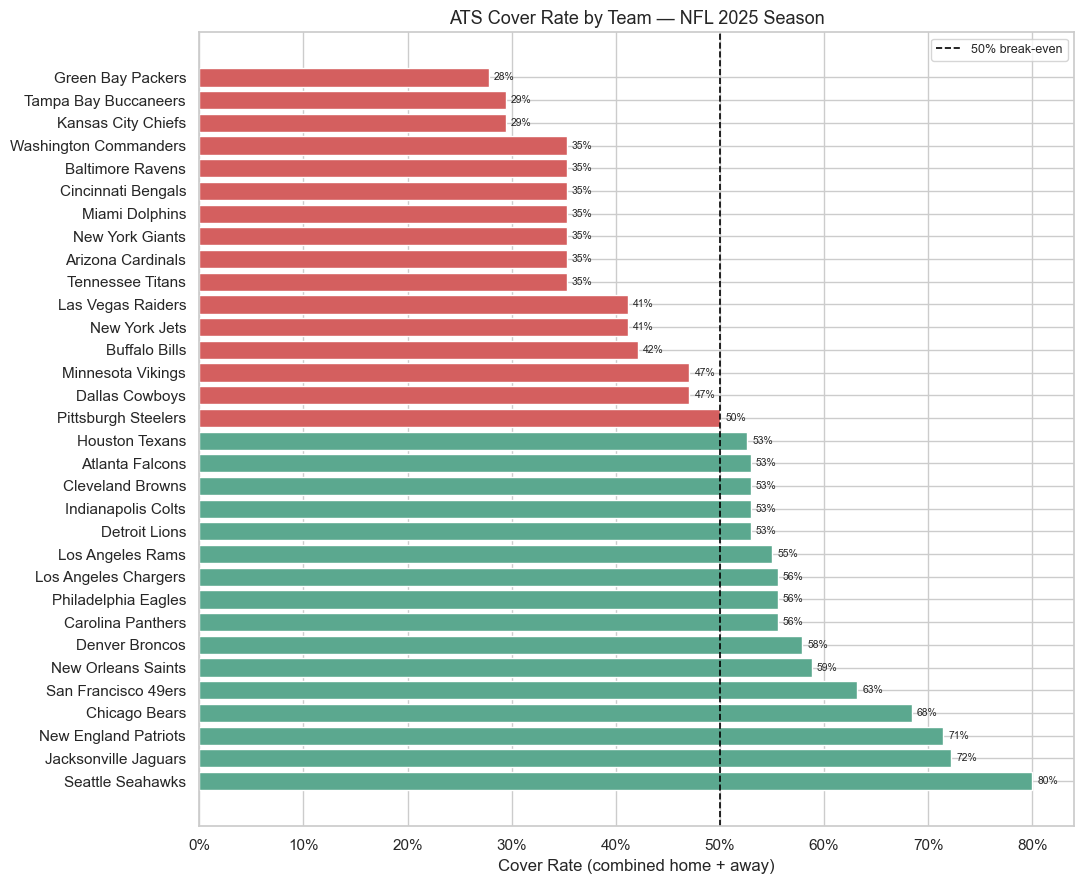

In [4]:
fig, ax = plt.subplots(figsize=(11, 9))
colors = ['#5ba88f' if r > 0.5 else '#d45f5f' for r in team_ats['cover_rate']]
bars = ax.barh(team_ats.index, team_ats['cover_rate'], color=colors, edgecolor='white')
ax.axvline(0.5, color='black', linestyle='--', linewidth=1.2, label='50% break-even')
ax.set_title('ATS Cover Rate by Team — NFL 2025 Season', fontsize=13)
ax.set_xlabel('Cover Rate (combined home + away)')
ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
ax.legend(fontsize=9)
for bar, val in zip(bars, team_ats['cover_rate']):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.0%}', va='center', fontsize=7.5)
plt.tight_layout()
plt.show()

## 4. Trap Teams vs. Underdog Value Teams

**What:** Scatter of win rate (x-axis) vs. ATS cover rate (y-axis) for all 32 teams, with a significance test on the most extreme cases.

**Trap teams (bottom-right):** High win rate, low cover rate. The public bets on their reputation, inflating the spread. They win games but rarely by enough to cover the inflated price. The Kansas City Chiefs at 29.4% ATS despite a .353 win rate is the standout — defending champions, heavily faded by the market, consistent failures to cover.

**Value teams (top-left):** Low win rate, high cover rate. The market overestimates the margin of their defeats — they lose games but cover frequently because the spread was too generous.

**Seattle special case:** Top-right quadrant — both high win rate AND high cover rate. The market consistently underpriced them even as they won. Statistically significant at p=0.012.

**Figure meaning:** Distance from the diagonal represents the gap between what the market expected and what happened. Extreme outliers in either quadrant represent the clearest systematic mispricing.

In [5]:
# Significance test on extremes
for team in ['Seattle Seahawks', 'Kansas City Chiefs', 'Green Bay Packers', 'Buffalo Bills']:
    row = team_ats.loc[team]
    t = binomtest(int(row['covers']), int(row['games']), p=0.5)
    print(f'{team:25s} | {int(row["covers"])}/{int(row["games"])} = {row["cover_rate"]:.1%} | p={t.pvalue:.4f} '
          f'{"★ significant" if t.pvalue < 0.05 else ""}')

print()
print('=== TRAP TEAMS (high win rate, low cover rate) ===')
trap = team_ats[(team_ats['win_rate'] > 0.45) & (team_ats['cover_rate'] < 0.45)]
print(trap[['games','wins','covers','win_rate','cover_rate']].round(3))

print()
print('=== UNDERDOG VALUE TEAMS (low win rate, high cover rate) ===')
value = team_ats[(team_ats['win_rate'] < 0.45) & (team_ats['cover_rate'] > 0.55)]
print(value[['games','wins','covers','win_rate','cover_rate']].round(3))

Seattle Seahawks          | 16/20 = 80.0% | p=0.0118 ★ significant
Kansas City Chiefs        | 5/17 = 29.4% | p=0.1435 
Green Bay Packers         | 5/18 = 27.8% | p=0.0963 
Buffalo Bills             | 8/19 = 42.1% | p=0.6476 

=== TRAP TEAMS (high win rate, low cover rate) ===
                      games  wins  covers  win_rate  cover_rate
team                                                           
Buffalo Bills            19    13       8     0.684       0.421
Baltimore Ravens         17     8       6     0.471       0.353
Tampa Bay Buccaneers     17     8       5     0.471       0.294
Green Bay Packers        18     9       5     0.500       0.278

=== UNDERDOG VALUE TEAMS (low win rate, high cover rate) ===
                    games  wins  covers  win_rate  cover_rate
team                                                         
New Orleans Saints     17     6      10     0.353       0.588
Carolina Panthers      18     8      10     0.444       0.556


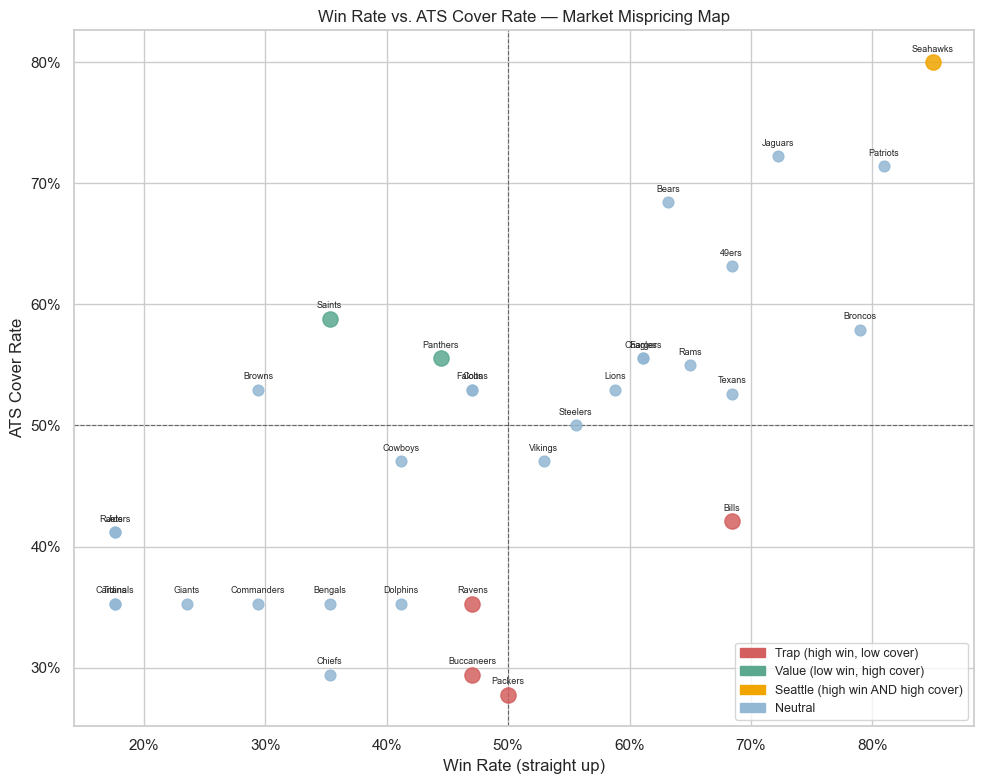

In [6]:
fig, ax = plt.subplots(figsize=(10, 8))

for team, row in team_ats.iterrows():
    is_trap  = row['win_rate'] > 0.45 and row['cover_rate'] < 0.45
    is_value = row['win_rate'] < 0.45 and row['cover_rate'] > 0.55
    is_sea   = team == 'Seattle Seahawks'
    color = '#d45f5f' if is_trap else '#5ba88f' if is_value else ('#f0a500' if is_sea else '#93b8d4')
    size  = 120 if (is_trap or is_value or is_sea) else 60
    ax.scatter(row['win_rate'], row['cover_rate'], color=color, s=size, zorder=3, alpha=0.85)
    ax.annotate(
        team.split()[-1],
        (row['win_rate'], row['cover_rate']),
        xytext=(0, 6), textcoords='offset points',
        fontsize=6.5, ha='center', va='bottom'
    )

ax.axhline(0.5, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
ax.axvline(0.5, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
ax.set_xlabel('Win Rate (straight up)')
ax.set_ylabel('ATS Cover Rate')
ax.set_title('Win Rate vs. ATS Cover Rate — Market Mispricing Map', fontsize=12)
ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))

ax.legend(handles=[
    mpatches.Patch(color='#d45f5f', label='Trap (high win, low cover)'),
    mpatches.Patch(color='#5ba88f', label='Value (low win, high cover)'),
    mpatches.Patch(color='#f0a500', label='Seattle (high win AND high cover)'),
    mpatches.Patch(color='#93b8d4', label='Neutral'),
], fontsize=9, loc='lower right')

plt.tight_layout()
plt.show()

## 5. Home vs. Away ATS Split

**What:** Break each team's cover rate into home games and away games separately.

**Why:** Home field advantage is already priced into the spread — typically worth 2.5–3 points. But some teams benefit more or less from home field than the market assumes, creating systematic venue-specific edges.

**Figure meaning:** Teams where the home and away bars diverge sharply are priced inconsistently by the market depending on venue. Cleveland Browns (home 77.8%, away 25.0%) and Denver Broncos (home 72.7%, away 37.5%) are the most extreme — their home performances are dramatically better vs. the spread than their road performances, suggesting the market underestimates their home advantage.

In [7]:
away_ats = df.groupby('away_team')['ats_away_cover'].agg(['sum','count','mean'])\
    .rename(columns={'sum':'away_covers','count':'away_games','mean':'away_rate'})
home_ats = df.groupby('home_team')['ats_home_cover'].agg(['sum','count','mean'])\
    .rename(columns={'sum':'home_covers','count':'home_games','mean':'home_rate'})

split = away_ats.join(home_ats, how='outer').fillna(0)
split['home_away_diff'] = split['home_rate'] - split['away_rate']
split = split.sort_values('home_away_diff', ascending=False)

print('Home vs. Away ATS split (sorted by home advantage gap):')
split[['away_games','away_rate','home_games','home_rate','home_away_diff']].round(3)

Home vs. Away ATS split (sorted by home advantage gap):


,away_games,away_rate,home_games,home_rate,home_away_diff
away_team,,,,,
Cleveland Browns,8,0.250,9,0.778,0.528
Denver Broncos,8,0.375,11,0.727,0.352
Los Angeles Rams,12,0.417,8,0.750,0.333
Kansas City Chiefs,8,0.125,9,0.444,0.319
Chicago Bears,9,0.556,10,0.800,0.244
Pittsburgh Steelers,8,0.375,10,0.600,0.225
Carolina Panthers,9,0.444,9,0.667,0.222
Los Angeles Chargers,9,0.444,9,0.667,0.222
Tennessee Titans,8,0.250,9,0.444,0.194


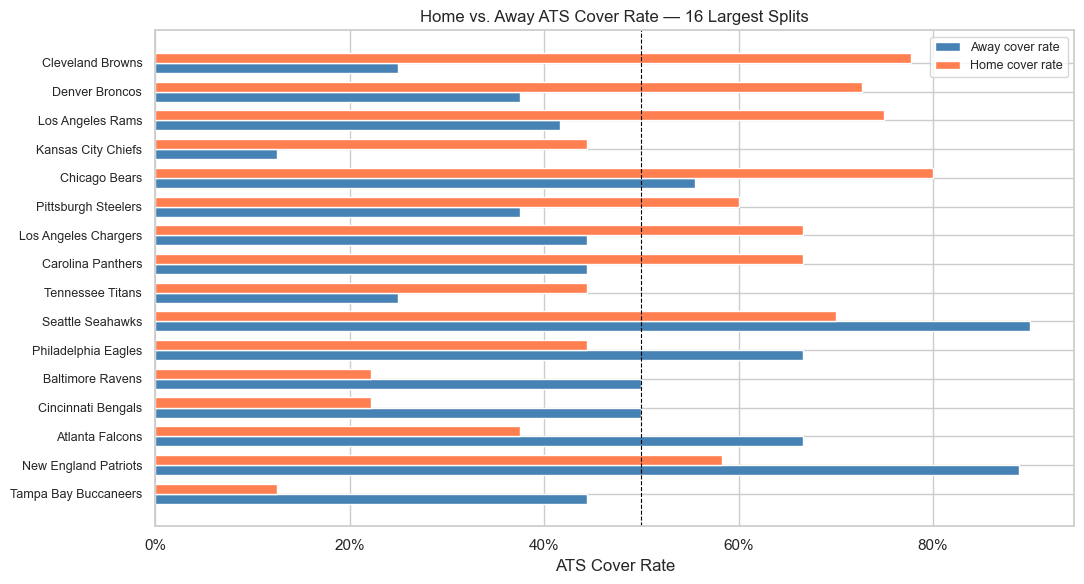

In [8]:
# Show top 16 largest absolute splits
top_split = split.reindex(split['home_away_diff'].abs().nlargest(16).index)
top_split = top_split.sort_values('home_away_diff', ascending=True)

fig, ax = plt.subplots(figsize=(11, 6))
x = np.arange(len(top_split))
w = 0.35
ax.barh(x - w/2, top_split['away_rate'], w, label='Away cover rate', color='steelblue', edgecolor='white')
ax.barh(x + w/2, top_split['home_rate'], w, label='Home cover rate', color='coral',     edgecolor='white')
ax.axvline(0.5, color='black', linestyle='--', linewidth=0.8)
ax.set_yticks(x)
ax.set_yticklabels(top_split.index, fontsize=9)
ax.set_xlabel('ATS Cover Rate')
ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
ax.set_title('Home vs. Away ATS Cover Rate — 16 Largest Splits', fontsize=12)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## 6. ATS by Week

**What:** Away cover rate grouped by week across the full 22-week season.

**Why:** If the market systematically misprices games early in the season (before enough performance data exists) and corrects later, we would expect higher variance in early weeks and convergence toward 50% as the season progresses.

**Playoffs note:** The Divisional round produced 0 away covers out of 4 games — all four home teams covered. The Conference Championship had the same result. These are small samples but consistent with home field mattering more in high-stakes games where top seeds have earned home field advantage.

**Figure meaning:** Bars above 50% = away teams beating the spread that week. High variance in individual weeks is expected given sample sizes of 14–16 games. The trend line shows whether there is systematic drift across the season.

In [9]:
weekly = (
    df[~df['ats_push']]
    .groupby(['week_num','week'])
    .agg(away_covers=('ats_away_cover','sum'), n=('ats_away_cover','count'))
    .assign(away_cover_rate=lambda x: x['away_covers'] / x['n'])
    .reset_index()
    .sort_values('week_num')
)

print('Away ATS cover rate by week:')
print(weekly[['week','away_covers','n','away_cover_rate']].to_string(index=False))

Away ATS cover rate by week:
week  away_covers  n  away_cover_rate
   1            7 15            0.467
   2            9 15            0.600
   3            5 15            0.333
   4            5 16            0.312
   5            9 14            0.643
   6            7 15            0.467
   7            6 15            0.400
   8            5 13            0.385
   9            9 14            0.643
  10            8 14            0.571
  11            5 14            0.357
  12            7 14            0.500
  13            9 16            0.562
  14            8 14            0.571
  15            7 16            0.438
  16           10 16            0.625
  17           10 16            0.625
  18            7 16            0.438
  WC            3  6            0.500
 DIV            0  4            0.000
  CC            0  2            0.000
  SB            1  1            1.000


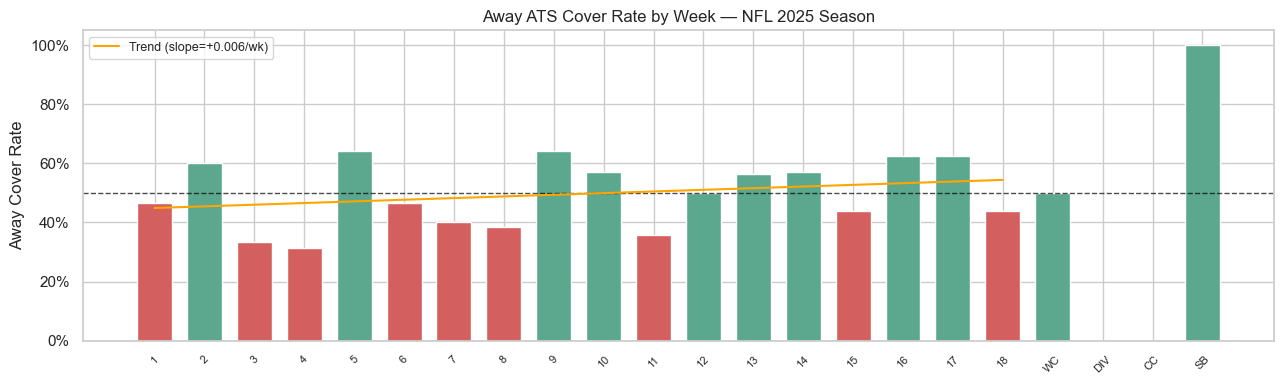

In [10]:
fig, ax = plt.subplots(figsize=(13, 4))
colors_w = ['#5ba88f' if v >= 0.5 else '#d45f5f' for v in weekly['away_cover_rate']]
ax.bar(range(len(weekly)), weekly['away_cover_rate'], color=colors_w, edgecolor='white', width=0.7)
ax.axhline(0.5, color='black', linestyle='--', linewidth=1, alpha=0.7)

# Trend line (regular season only)
reg = weekly[weekly['week_num'] < 18]
z = np.polyfit(reg['week_num'], reg['away_cover_rate'], 1)
p = np.poly1d(z)
ax.plot(range(len(reg)), p(reg['week_num']), color='orange', linewidth=1.5,
        linestyle='-', label=f'Trend (slope={z[0]:+.3f}/wk)')

ax.set_xticks(range(len(weekly)))
ax.set_xticklabels(weekly['week'].astype(str), rotation=45, fontsize=8)
ax.set_ylabel('Away Cover Rate')
ax.set_title('Away ATS Cover Rate by Week — NFL 2025 Season', fontsize=12)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## 7. Over/Under Analysis

**What:** Season-wide over/under results, team-level over rates, and a significance test on whether the total market is systematically biased.

**Why totals matter:** The over/under market is subject to the same sharp vs. public dynamics as the spread. The public tends to overestimate scoring — they bet overs because high-scoring games are more exciting. If sharps systematically fade that tendency, totals should drift down (as we saw in Notebook 3) and the under should hit slightly more often.

**Figure meaning:** The team over rate chart identifies which teams consistently play in higher or lower-scoring games than the market expects. Teams above 60% are systematically under-priced on totals; teams below 40% are over-priced. Kansas City Chiefs at 23.5% over rate is the most extreme — suggesting their games were consistently priced too high on scoring.

In [11]:
n_ou = len(df[~df['ou_push']])
ou_test = binomtest(int(df['over_hit'].sum()), n_ou, p=0.5)

print('=== SEASON O/U RESULTS ===')
print(f'Over  : {df["over_hit"].sum()} ({df["over_hit"].sum()/n_ou:.1%})')
print(f'Under : {df["under_hit"].sum()} ({df["under_hit"].sum()/n_ou:.1%})')
print(f'Push  : {df["ou_push"].sum()}')
print(f'Binomial p-value: {ou_test.pvalue:.4f}')
if ou_test.pvalue > 0.05:
    print('  → No significant over/under bias. Total market is well-calibrated at the aggregate level.')

# ── Team O/U ──────────────────────────────────────────────────────────────────
ou_rows = []
for _, r in df.iterrows():
    if not r['ou_push']:
        ou_rows.append({'team': r['away_team'], 'over': r['over_hit']})
        ou_rows.append({'team': r['home_team'], 'over': r['over_hit']})

ou_df = pd.DataFrame(ou_rows)
team_ou = ou_df.groupby('team').agg(
    games=('over','count'), overs=('over','sum'), over_rate=('over','mean')
).sort_values('over_rate', ascending=False)

print()
print('O/U Over Rate by Team (top 8 and bottom 8):')
pd.concat([team_ou.head(8), team_ou.tail(8)])[['games','overs','over_rate']].round(3)

=== SEASON O/U RESULTS ===
Over  : 140 (49.6%)
Under : 142 (50.4%)
Push  : 3
Binomial p-value: 0.9525
  → No significant over/under bias. Total market is well-calibrated at the aggregate level.

O/U Over Rate by Team (top 8 and bottom 8):


,games,overs,over_rate
team,,,
Dallas Cowboys,17,11,0.647
Tennessee Titans,17,11,0.647
New York Jets,17,11,0.647
Los Angeles Rams,20,12,0.600
Arizona Cardinals,17,10,0.588
New York Giants,17,10,0.588
Detroit Lions,17,10,0.588
Washington Commanders,17,10,0.588
Chicago Bears,18,7,0.389


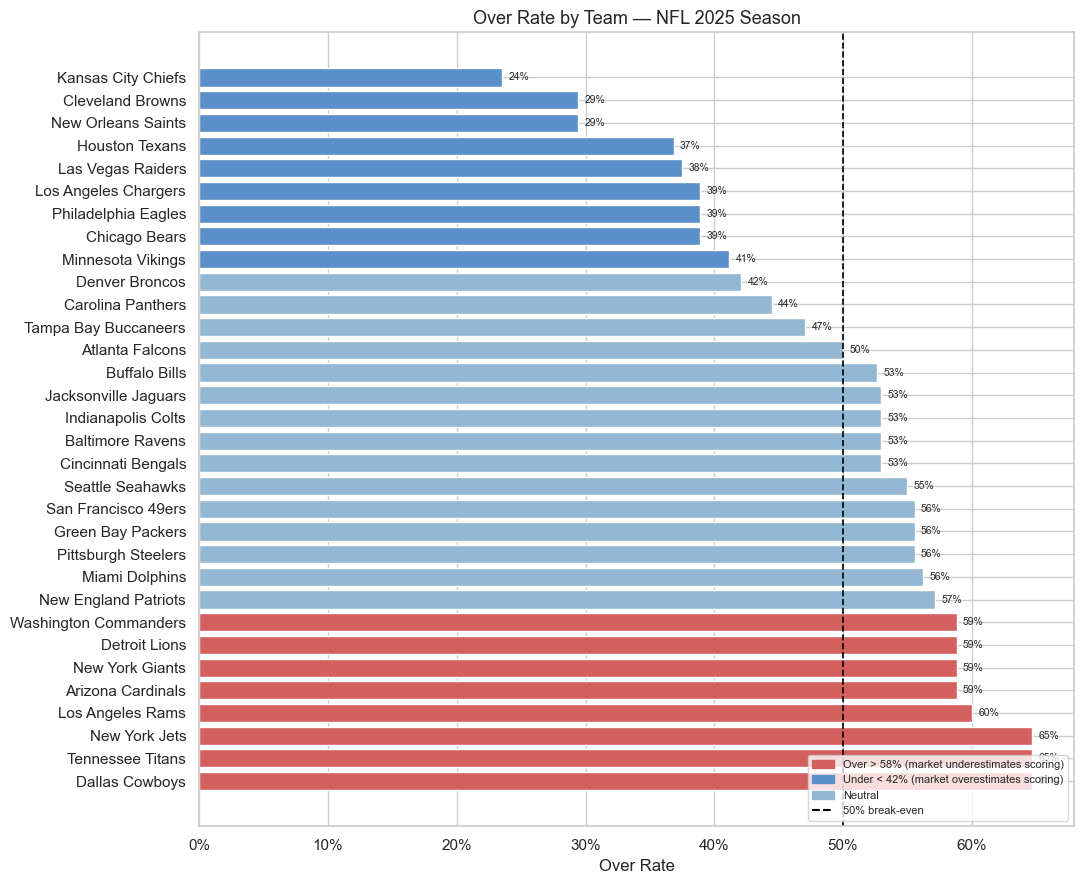

In [12]:
fig, ax = plt.subplots(figsize=(11, 9))
colors_ou = ['#d45f5f' if r > 0.58 else '#5b8fc9' if r < 0.42 else '#93b8d4'
             for r in team_ou['over_rate']]
bars = ax.barh(team_ou.index, team_ou['over_rate'], color=colors_ou, edgecolor='white')
ax.axvline(0.5, color='black', linestyle='--', linewidth=1.2, label='50% break-even')
ax.set_title('Over Rate by Team — NFL 2025 Season', fontsize=13)
ax.set_xlabel('Over Rate')
ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
ax.legend(handles=[
    mpatches.Patch(color='#d45f5f', label='Over > 58% (market underestimates scoring)'),
    mpatches.Patch(color='#5b8fc9', label='Under < 42% (market overestimates scoring)'),
    mpatches.Patch(color='#93b8d4', label='Neutral'),
    plt.Line2D([0],[0], color='black', linestyle='--', label='50% break-even')
], fontsize=8, loc='lower right')
for bar, val in zip(bars, team_ou['over_rate']):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.0%}', va='center', fontsize=7.5)
plt.tight_layout()
plt.show()

## 8. Export

In [13]:
os.makedirs('../outputs', exist_ok=True)

team_ats.to_csv('../outputs/5_team_ats.csv')
split.to_csv('../outputs/5_home_away_ats_split.csv')
team_ou.to_csv('../outputs/5_team_ou.csv')
weekly[['week','week_num','away_covers','n','away_cover_rate']].to_csv('../outputs/5_weekly_ats.csv', index=False)

export_cols = [
    'week','away_team','home_team','winner',
    'opener_away_spread','actual_margin',
    'ats_away_cover','ats_home_cover','ats_push',
    'opener_total_line','actual_total',
    'over_hit','under_hit','ou_push',
]
df[export_cols].to_csv('../outputs/5_game_ats_ou.csv', index=False)

print('Exported:')
print(f'  5_team_ats.csv             — {len(team_ats)} teams')
print(f'  5_home_away_ats_split.csv  — {len(split)} teams')
print(f'  5_team_ou.csv              — {len(team_ou)} teams')
print(f'  5_weekly_ats.csv           — {len(weekly)} weeks')
print(f'  5_game_ats_ou.csv          — {len(df)} games')

Exported:
  5_team_ats.csv             — 32 teams
  5_home_away_ats_split.csv  — 32 teams
  5_team_ou.csv              — 32 teams
  5_weekly_ats.csv           — 22 weeks
  5_game_ats_ou.csv          — 285 games


---

## 5 — Key Findings

### 1. Overall ATS — Market Is Well-Calibrated

Across 281 non-push games, away teams covered 137 times (48.8%) and home teams 144 times (51.2%). The binomial test returns p = 0.7205 — no statistically significant home or away bias. The spread market is doing its job at the aggregate level. Any edges must be found at the team level, not in systematic home/away pricing.

---

### 2. ATS by Team — The Full 32-Team Ledger

| Team | Games | Covers | Cover Rate | Win Rate |
|------|-------|--------|-----------|----------|
| **Seattle Seahawks** ★ | 20 | 16 | **80.0%** | 85.0% |
| Jacksonville Jaguars | 18 | 13 | 72.2% | 72.2% |
| New England Patriots | 21 | 15 | 71.4% | 81.0% |
| Chicago Bears | 19 | 13 | 68.4% | 63.2% |
| San Francisco 49ers | 19 | 12 | 63.2% | 68.4% |
| … | | | | |
| Kansas City Chiefs | 17 | 5 | 29.4% | 35.3% |
| Tampa Bay Buccaneers | 17 | 5 | 29.4% | 47.1% |
| **Green Bay Packers** | 18 | 5 | **27.8%** | 50.0% |

★ Seattle's 80% cover rate is the only statistically significant result in the dataset (p = 0.012). The market consistently underpriced them throughout the season — their spread was set below what their actual performance justified, game after game.

Green Bay is the inverse extreme at 27.8% — the market overrated them all season. A team with a 50% win rate covering fewer than 3 in 10 games is a systematic pricing failure.

---

### 3. Trap Teams vs. Underdog Value Teams

**Trap teams** (high win rate, low cover rate — public money inflates the spread):

| Team | Win Rate | Cover Rate | Gap |
|------|----------|-----------|-----|
| Buffalo Bills | 68.4% | 42.1% | −26.3pp |
| Green Bay Packers | 50.0% | 27.8% | −22.2pp |
| Tampa Bay Buccaneers | 47.1% | 29.4% | −17.6pp |
| Baltimore Ravens | 47.1% | 35.3% | −11.8pp |

The Buffalo Bills are the most interesting trap — 68.4% win rate (genuine contender) but only 42.1% cover rate. Their strong brand pulled public money all season, inflating the spread beyond what even a good team could consistently beat.

**Underdog value teams** (low win rate, high cover rate — market overestimates their defeats):

| Team | Win Rate | Cover Rate |
|------|----------|-----------|
| New Orleans Saints | 35.3% | 58.8% |
| Carolina Panthers | 44.4% | 55.6% |

Both lose games regularly, but cover well above 50% — the market consistently set their spreads too wide.

---

### 4. Home vs. Away ATS Splits — Venue Mispricing

The largest home-advantage gaps in cover rate (home rate − away rate):

| Team | Away Cover % | Home Cover % | Gap |
|------|-------------|-------------|-----|
| Cleveland Browns | 25.0% | **77.8%** | +52.8pp |
| Denver Broncos | 37.5% | **72.7%** | +35.2pp |
| Los Angeles Rams | 41.7% | **75.0%** | +33.3pp |
| Kansas City Chiefs | 12.5% | 44.4% | +31.9pp |

Teams going the other way (cover better on the road than at home):

| Team | Away Cover % | Home Cover % | Gap |
|------|-------------|-------------|-----|
| Tampa Bay Buccaneers | 44.4% | **12.5%** | −31.9pp |
| New England Patriots | **88.9%** | 58.3% | −30.6pp |
| Atlanta Falcons | **66.7%** | 37.5% | −29.2pp |
| Seattle Seahawks | **90.0%** | 70.0% | −20.0pp |

New England's away cover rate of 88.9% (8/9 road games covered) is the most extraordinary single-venue stat in the dataset. The market consistently underestimated them as away underdogs. Seattle covered 9 of 10 road games — the market underpriced them even more on the road than at home.

---

### 5. ATS by Week — No Systematic Trend

Weekly away cover rates ranged from 31.2% (Week 4) to 64.3% (Weeks 5 and 9), with no statistically significant trend across the regular season. The market did not systematically improve or worsen its calibration as the season progressed.

**Playoffs: home teams dominated the spread.** The Divisional round produced 0 away covers out of 4 games (0.0%). The Conference Championship round also produced 0 away covers out of 2 games (0.0%). Six straight playoff games where the spread underestimated the home team's performance — consistent with the widely-held view that home field advantage is underpriced in playoff spreads.

---

### 6. Over/Under — Efficient Market, Extreme Teams

The total market was nearly perfectly balanced: 140 overs (49.6%) vs. 142 unders (50.4%), push 3. Binomial p = 0.9525. No aggregate bias.

At the team level, extreme outliers exist:

| Team | Over Rate | Interpretation |
|------|-----------|----------------|
| Dallas Cowboys | 64.7% | Market underpriced scoring in Cowboys games |
| Tennessee Titans | 64.7% | Same |
| New York Jets | 64.7% | Same |
| **Kansas City Chiefs** | **23.5%** | Market consistently set KC totals too high |
| Cleveland Browns | 29.4% | Same |
| New Orleans Saints | 29.4% | Same |

The Kansas City Chiefs appear at the bottom of both the ATS table (29.4% cover rate) and the O/U table (23.5% over rate) — the market overestimated them in both dimensions across the full season.

---

### Summary Table

| Metric | Value |
|--------|-------|
| Overall away cover rate | 48.8% (p=0.72, not significant) |
| Overall over rate | 49.6% (p=0.95, not significant) |
| Best ATS team | Seattle Seahawks 80.0% ★ (p=0.012) |
| Worst ATS team | Green Bay Packers 27.8% |
| Biggest trap | Buffalo Bills (68.4% win rate, 42.1% cover) |
| Best underdog value | New Orleans Saints (35.3% win, 58.8% cover) |
| Biggest venue split | Cleveland Browns (+52.8pp home vs. away) |
| Best road cover team | New England Patriots 88.9% away |
| Highest over rate | Cowboys / Titans / Jets (64.7%) |
| Lowest over rate | Kansas City Chiefs (23.5%) |
| Playoff away covers | 0/6 in DIV + CC rounds |

> **Next:** Notebook 6 builds on these findings using opener vs. closing line movement as a sharp money proxy — identifying which games saw the most significant informed betting activity and whether those moves predicted outcomes.
